# 17_model_surf_score.ipynb — Módulo final de surf score

Este notebook consolida el módulo de **surf score** de DeepWave Canarias.

Objetivo:

```text
Evaluar y consolidar un score de surf de 0 a 10 y una categoría de calidad:
poor / fair / good / very_good / epic
```

Entrada principal:

```text
gold/multitarget_training_dataset/
```

Entrada opcional:

```text
gold/model_results/multitarget_physical/predictions_val_test_core_targets.parquet
```

Compara:

```text
CurrentConditionsSurfScore
PhysicalDerivedSurfScore
DirectLGBMSurfScore
```

Nota importante:

```text
El surf score es una etiqueta derivada por reglas físicas interpretables.
No procede de valoraciones reales de surfistas.
```

Este notebook está preparado para ejecutarse en **Mac** con la estructura:

```text
deep-wave-canarias/
├── gold/
├── models/
└── notebooks/
```

## Celda 0 — Entorno local / Colab

In [1]:
import sys

if "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive")
else:
    print("Entorno local detectado. No se monta Google Drive.")

Entorno local detectado. No se monta Google Drive.


## Celda 1 — Dependencias

In [2]:
# En Mac puedes saltar esta celda si ya tienes todo instalado.
# Si falta algo, instala en terminal:
# pip install lightgbm pandas numpy pyarrow scikit-learn matplotlib joblib psutil tqdm

import sys

if "google.colab" in sys.modules:
    !pip -q install lightgbm pandas numpy pyarrow scikit-learn matplotlib joblib psutil tqdm
else:
    print("Dependencias esperadas: pandas numpy pyarrow scikit-learn matplotlib joblib psutil tqdm lightgbm")

Dependencias esperadas: pandas numpy pyarrow scikit-learn matplotlib joblib psutil tqdm lightgbm


## Celda 2 — Imports, rutas y configuración

In [3]:
from pathlib import Path
import os
import sys
import json
import gc
import platform
import warnings
import joblib

import numpy as np
import pandas as pd
import pyarrow.dataset as ds

from tqdm.auto import tqdm

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix,
)

import matplotlib.pyplot as plt

try:
    import psutil
except Exception:
    psutil = None

try:
    import lightgbm as lgb
    from lightgbm import LGBMRegressor
    LIGHTGBM_AVAILABLE = True
except Exception:
    LIGHTGBM_AVAILABLE = False
    lgb = None
    LGBMRegressor = None

warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------
# RUTAS — MAC FIRST
# ---------------------------------------------------------------------
LOCAL_BASE_DIR = Path.cwd().parent
LOCAL_INPUT_GOLD_DIR = None

RUNNING_IN_COLAB = "google.colab" in sys.modules

def resolve_paths():
    if RUNNING_IN_COLAB:
        base_dir = Path("/content/drive/MyDrive/AI Projects/DeepWave Canarias")
        input_dir = base_dir / "gold" / "multitarget_training_dataset"
        return base_dir, input_dir

    if LOCAL_INPUT_GOLD_DIR is not None:
        input_dir = Path(LOCAL_INPUT_GOLD_DIR).expanduser().resolve()
        if not input_dir.exists():
            raise FileNotFoundError(f"LOCAL_INPUT_GOLD_DIR no existe: {input_dir}")
        base_dir = input_dir.parent.parent
        return base_dir, input_dir

    base_dir = Path(LOCAL_BASE_DIR).expanduser().resolve()
    input_dir = base_dir / "gold" / "multitarget_training_dataset"
    return base_dir, input_dir

BASE_DIR, INPUT_GOLD_DIR = resolve_paths()

GOLD_DIR = BASE_DIR / "gold"
MODELS_DIR = BASE_DIR / "models" / "surf_score"
RESULTS_DIR = GOLD_DIR / "model_results" / "surf_score"
PHYSICAL_RESULTS_DIR = GOLD_DIR / "model_results" / "multitarget_physical"
REPORT_DIR = GOLD_DIR / "_quality_reports"
META_DIR = GOLD_DIR / "_metadata"

for d in [MODELS_DIR, RESULTS_DIR, REPORT_DIR, META_DIR]:
    d.mkdir(parents=True, exist_ok=True)

if not INPUT_GOLD_DIR.exists():
    raise FileNotFoundError(
        "No existe gold/multitarget_training_dataset/. Ejecuta primero 14_gold_multitarget_dataset.ipynb.\n"
        f"Ruta esperada: {INPUT_GOLD_DIR}"
    )

# ---------------------------------------------------------------------
# CONFIGURACIÓN
# ---------------------------------------------------------------------
HORIZONS_HOURS = [3, 6, 12, 24, 48]

QUALITY_ORDER = ["poor", "fair", "good", "very_good", "epic"]
QUALITY_TO_INT = {v: i for i, v in enumerate(QUALITY_ORDER)}
INT_TO_QUALITY = {i: v for v, i in QUALITY_TO_INT.items()}

RANDOM_STATE = 42
N_JOBS = -1

# Entrenamiento opcional: modelo directo que aprende target_surf_score.
# Es útil como comparación, aunque la opción más interpretable suele ser PhysicalDerivedSurfScore.
TRAIN_DIRECT_LGBM_SCORE = True and LIGHTGBM_AVAILABLE

USE_ZONA_ID_AS_FEATURE = True
MAX_MISSING_PCT_FEATURE = 98.5
MAX_FEATURES = None

MAX_TRAIN_ROWS_PER_MODEL = None
MAX_VAL_ROWS_PER_MODEL = None
MAX_TEST_ROWS_PER_MODEL = None

LGBM_N_ESTIMATORS = 2500
LGBM_LEARNING_RATE = 0.025
LGBM_EARLY_STOPPING_ROUNDS = 120

SENTINEL_VALUES = [-9999, -9999.0, -9999.9, -99999, -99999.0, -1e20, 1e20]

SURF_SCORE_CONFIG = {
    "ideal_hs_min": 0.8,
    "ideal_hs_max": 2.5,
    "ideal_period_min": 9.0,
    "ideal_period_good": 12.0,
    "bad_wind_speed": 10.0,
    "very_bad_wind_speed": 14.0,
}

PHYSICAL_PREDICTIONS_PATH = PHYSICAL_RESULTS_DIR / "predictions_val_test_core_targets.parquet"

print("Sistema:", platform.platform())
print("BASE_DIR:", BASE_DIR)
print("INPUT_GOLD_DIR:", INPUT_GOLD_DIR)
print("RESULTS_DIR:", RESULTS_DIR)
print("MODELS_DIR:", MODELS_DIR)
print("LightGBM disponible:", LIGHTGBM_AVAILABLE)
if LIGHTGBM_AVAILABLE:
    print("LightGBM:", lgb.__version__)
print("TRAIN_DIRECT_LGBM_SCORE:", TRAIN_DIRECT_LGBM_SCORE)
print("Predicciones físicas:", PHYSICAL_PREDICTIONS_PATH, "existe:", PHYSICAL_PREDICTIONS_PATH.exists())

if psutil is not None:
    mem = psutil.virtual_memory()
    print(f"RAM total: {mem.total / 1024**3:.1f} GB")
    print(f"RAM disponible: {mem.available / 1024**3:.1f} GB")

Sistema: macOS-26.3.1-arm64-arm-64bit
BASE_DIR: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias
INPUT_GOLD_DIR: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/multitarget_training_dataset
RESULTS_DIR: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/surf_score
MODELS_DIR: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/models/surf_score
LightGBM disponible: True
LightGBM: 4.6.0
TRAIN_DIRECT_LGBM_SCORE: True
Predicciones físicas: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/multitarget_physical/predictions_val_test_core_targets.parquet existe: True
RAM total: 16.0 GB
RAM disponible: 2.5 GB


## Celda 3 — Funciones auxiliares

In [4]:
def ensure_utc(series):
    return pd.to_datetime(series, utc=True, errors="coerce")


def memory_report(name, df):
    mb = df.memory_usage(deep=True).sum() / 1024 / 1024
    print(f"{name}: shape={df.shape}, memoria≈{mb:.1f} MB")


def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False, default=str)


def sample_df(df, max_rows, random_state=RANDOM_STATE):
    if max_rows is None or len(df) <= max_rows:
        return df
    return df.sample(n=max_rows, random_state=random_state).sort_index()


def clean_sentinel_values(df):
    numeric_cols = df.select_dtypes(include=[np.number, "boolean"]).columns.tolist()
    for c in tqdm(numeric_cols, desc="Limpiando sentinelas"):
        if pd.api.types.is_bool_dtype(df[c]):
            continue
        df[c] = pd.to_numeric(df[c], errors="coerce").replace(SENTINEL_VALUES, np.nan)
    return df


def coast_orientation_to_degrees(value):
    if pd.isna(value):
        return np.nan
    v = str(value).strip().upper()
    mapping = {"N": 0, "NE": 45, "E": 90, "SE": 135, "S": 180, "SW": 225, "W": 270, "NW": 315}
    return mapping.get(v, np.nan)


def angular_diff_deg(a, b):
    a = pd.to_numeric(a, errors="coerce")
    b = pd.to_numeric(b, errors="coerce")
    return np.abs((a - b + 180) % 360 - 180)


def surf_score_from_conditions(hs, period=None, wind_speed=None, wave_direction=None, wind_direction=None, coast_orientation_deg=None):
    hs = pd.to_numeric(hs, errors="coerce")
    idx = hs.index

    if period is None:
        period = pd.Series(np.nan, index=idx)
    else:
        period = pd.to_numeric(period, errors="coerce")

    if wind_speed is None:
        wind_speed = pd.Series(np.nan, index=idx)
    else:
        wind_speed = pd.to_numeric(wind_speed, errors="coerce")

    score = pd.Series(0.0, index=idx, dtype="float64")

    score += np.where(hs.between(SURF_SCORE_CONFIG["ideal_hs_min"], SURF_SCORE_CONFIG["ideal_hs_max"]), 3.0, 0.0)
    score += np.where(hs.between(0.5, 3.0), 1.0, 0.0)
    score -= np.where(hs < 0.4, 2.0, 0.0)
    score -= np.where(hs > 3.5, 1.5, 0.0)

    score += np.where(period >= SURF_SCORE_CONFIG["ideal_period_min"], 2.0, 0.0)
    score += np.where(period >= SURF_SCORE_CONFIG["ideal_period_good"], 1.0, 0.0)

    score += np.where(wind_speed <= 5.0, 1.0, 0.0)
    score -= np.where(wind_speed >= SURF_SCORE_CONFIG["bad_wind_speed"], 1.0, 0.0)
    score -= np.where(wind_speed >= SURF_SCORE_CONFIG["very_bad_wind_speed"], 1.0, 0.0)

    orientation_scores = []

    if wave_direction is not None and coast_orientation_deg is not None:
        wave_diff = angular_diff_deg(wave_direction, coast_orientation_deg)
        wave_alignment = (np.cos(np.deg2rad(wave_diff)) + 1) / 2
        orientation_scores.append(pd.Series(wave_alignment, index=idx).clip(0, 1))

    if wind_direction is not None and coast_orientation_deg is not None:
        wind_diff = angular_diff_deg(wind_direction, coast_orientation_deg)
        wind_offshore = pd.Series(wind_diff / 180.0, index=idx).clip(0, 1)
        orientation_scores.append(wind_offshore)

    if orientation_scores:
        offshore_score = pd.concat(orientation_scores, axis=1).mean(axis=1).fillna(0.5)
    else:
        offshore_score = pd.Series(0.5, index=idx)

    score += offshore_score.clip(0, 1) * 2.0
    score = score.where(hs.notna())

    return score.clip(0, 10).astype("float32")


def surf_quality_label(score):
    score = pd.to_numeric(score, errors="coerce")
    out = pd.Series(pd.NA, index=score.index, dtype="string")
    out.loc[score < 2] = "poor"
    out.loc[(score >= 2) & (score < 4)] = "fair"
    out.loc[(score >= 4) & (score < 6)] = "good"
    out.loc[(score >= 6) & (score < 8)] = "very_good"
    out.loc[score >= 8] = "epic"
    return out


def regression_metrics(y_true, y_pred):
    y_true = pd.Series(np.asarray(y_true), dtype="float64")
    y_pred = pd.Series(np.asarray(y_pred), dtype="float64")
    mask = y_true.notna() & y_pred.notna()

    if mask.sum() == 0:
        return {"n": 0, "mae": np.nan, "rmse": np.nan, "r2": np.nan, "bias": np.nan, "corr": np.nan}

    yt = y_true[mask].values
    yp = y_pred[mask].values

    return {
        "n": int(mask.sum()),
        "mae": float(mean_absolute_error(yt, yp)),
        "rmse": float(np.sqrt(mean_squared_error(yt, yp))),
        "r2": float(r2_score(yt, yp)) if len(np.unique(yt)) > 1 else np.nan,
        "bias": float(np.mean(yp - yt)),
        "corr": float(np.corrcoef(yt, yp)[0, 1]) if len(yt) > 1 and np.std(yt) > 0 and np.std(yp) > 0 else np.nan,
    }


def quality_metrics(y_true, y_pred):
    yt = pd.Series(y_true, dtype="string")
    yp = pd.Series(y_pred, dtype="string")
    mask = yt.notna() & yp.notna()

    out = {
        "n_quality": int(mask.sum()),
        "quality_accuracy": np.nan,
        "quality_balanced_accuracy": np.nan,
        "quality_macro_f1": np.nan,
        "quality_weighted_f1": np.nan,
    }

    for label in QUALITY_ORDER:
        out[f"quality_precision_{label}"] = np.nan
        out[f"quality_recall_{label}"] = np.nan
        out[f"quality_f1_{label}"] = np.nan
        out[f"quality_support_{label}"] = 0

    if mask.sum() == 0:
        return out

    yti = yt[mask].map(QUALITY_TO_INT).astype("Int64")
    ypi = yp[mask].map(QUALITY_TO_INT).astype("Int64")
    valid = yti.notna() & ypi.notna()

    if valid.sum() == 0:
        return out

    yti = yti[valid].astype(int).values
    ypi = ypi[valid].astype(int).values
    labels = list(range(len(QUALITY_ORDER)))

    out["quality_accuracy"] = float(accuracy_score(yti, ypi))
    out["quality_balanced_accuracy"] = float(balanced_accuracy_score(yti, ypi))
    out["quality_macro_f1"] = float(f1_score(yti, ypi, labels=labels, average="macro", zero_division=0))
    out["quality_weighted_f1"] = float(f1_score(yti, ypi, labels=labels, average="weighted", zero_division=0))

    precision, recall, f1, support = precision_recall_fscore_support(yti, ypi, labels=labels, zero_division=0)

    for i, label in enumerate(QUALITY_ORDER):
        out[f"quality_precision_{label}"] = float(precision[i])
        out[f"quality_recall_{label}"] = float(recall[i])
        out[f"quality_f1_{label}"] = float(f1[i])
        out[f"quality_support_{label}"] = int(support[i])

    return out


def evaluate_surf_prediction(model_name, horizon, split_name, y_score_true, y_score_pred, y_quality_true=None, y_quality_pred=None):
    score_metrics = regression_metrics(y_score_true, y_score_pred)

    if y_quality_true is None:
        y_quality_true = surf_quality_label(y_score_true)
    if y_quality_pred is None:
        y_quality_pred = surf_quality_label(y_score_pred)

    q_metrics = quality_metrics(y_quality_true, y_quality_pred)

    return {
        "model": model_name,
        "horizon_hours": horizon,
        "split": split_name,
        **score_metrics,
        **q_metrics,
    }


def build_lgbm_regressor(horizon):
    return LGBMRegressor(
        objective="regression",
        n_estimators=LGBM_N_ESTIMATORS,
        learning_rate=LGBM_LEARNING_RATE,
        num_leaves=96,
        max_depth=-1,
        min_child_samples=60,
        subsample=0.85,
        subsample_freq=1,
        colsample_bytree=0.85,
        reg_alpha=0.05,
        reg_lambda=0.20,
        random_state=RANDOM_STATE + int(horizon),
        n_jobs=N_JOBS,
        importance_type="gain",
        verbosity=-1,
    )


def fit_lgbm_regressor(model, X_train, y_train, X_val, y_val):
    callbacks = [
        lgb.early_stopping(LGBM_EARLY_STOPPING_ROUNDS, verbose=False),
        lgb.log_evaluation(period=250),
    ]

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="rmse",
        callbacks=callbacks,
    )

    return model


def model_safe_name(name):
    return str(name).replace("/", "_").replace(" ", "_").replace(":", "_")


def get_current_columns(df):
    hs_col = "simar_hs" if "simar_hs" in df.columns else ("hs" if "hs" in df.columns else None)
    period_col = "simar_tp" if "simar_tp" in df.columns else ("simar_tm02" if "simar_tm02" in df.columns else None)
    wind_speed_col = "simar_wind_speed" if "simar_wind_speed" in df.columns else ("wind_speed" if "wind_speed" in df.columns else None)
    wave_dir_col = "simar_wave_direction" if "simar_wave_direction" in df.columns else ("wave_direction" if "wave_direction" in df.columns else None)
    wind_dir_col = "simar_wind_direction" if "simar_wind_direction" in df.columns else ("wind_direction" if "wind_direction" in df.columns else None)
    return hs_col, period_col, wind_speed_col, wave_dir_col, wind_dir_col

## Celda 4 — Cargar Gold multitarget

In [5]:
dataset = ds.dataset(str(INPUT_GOLD_DIR), format="parquet", partitioning="hive")
gold = dataset.to_table().to_pandas()

gold["timestamp"] = ensure_utc(gold["timestamp"])
gold["split"] = gold["split"].astype(str)
gold["zona_id"] = gold["zona_id"].astype(str)

if "isla" in gold.columns:
    gold["isla"] = gold["isla"].astype("string").fillna("UNKNOWN")
else:
    gold["isla"] = "UNKNOWN"

gold = gold.sort_values(["zona_id", "timestamp"]).reset_index(drop=True)
gold = clean_sentinel_values(gold)

if "coast_orientation_deg" not in gold.columns:
    if "orientacion_costa" in gold.columns:
        gold["coast_orientation_deg"] = gold["orientacion_costa"].map(coast_orientation_to_degrees).astype("float32")
    else:
        gold["coast_orientation_deg"] = np.nan

print("Gold multitarget cargado:")
memory_report("gold", gold)

print("Periodo:")
print(gold["timestamp"].min(), "→", gold["timestamp"].max())

print("Splits:")
display(gold["split"].value_counts(dropna=False).reset_index())

print("Zonas:", gold["zona_id"].nunique())
print("Columnas:", len(gold.columns))

display(gold.head())

Limpiando sentinelas:   0%|          | 0/651 [00:00<?, ?it/s]

Gold multitarget cargado:
gold: shape=(983328, 669), memoria≈2487.4 MB
Periodo:
2015-01-01 00:00:00+00:00 → 2025-12-31 23:00:00+00:00
Splits:


,split,count
0,train,698712
1,test,197256
2,val,87360


Zonas: 14
Columnas: 669


,timestamp,zona_id,simar_ocean_lat,simar_ocean_lon,simar_hs,simar_hmax,simar_tp,simar_tm02,simar_wave_direction,simar_swell_height,...,is_trainable_multitarget_12h,is_trainable_risk_12h,is_trainable_physical_24h,is_trainable_multitarget_24h,is_trainable_risk_24h,is_trainable_physical_48h,is_trainable_multitarget_48h,is_trainable_risk_48h,split,year
0,2025-05-06 00:00:00+00:00,CAN_EH_PUERTO_DE_LA_ESTACA,27.75,-17.666666,0.97,NaN,9.10,4.07,2,0.44,...,False,True,True,False,True,True,False,True,test,2025
1,2025-05-06 01:00:00+00:00,CAN_EH_PUERTO_DE_LA_ESTACA,27.75,-17.666666,0.94,NaN,10.01,4.19,358,0.47,...,False,True,True,False,True,True,False,True,test,2025
2,2025-05-06 02:00:00+00:00,CAN_EH_PUERTO_DE_LA_ESTACA,27.75,-17.666666,0.91,NaN,10.01,4.48,352,0.50,...,False,True,True,False,True,True,False,True,test,2025
3,2025-05-06 03:00:00+00:00,CAN_EH_PUERTO_DE_LA_ESTACA,27.75,-17.666666,0.90,NaN,12.11,4.78,349,0.52,...,False,True,True,False,True,True,False,True,test,2025
4,2025-05-06 04:00:00+00:00,CAN_EH_PUERTO_DE_LA_ESTACA,27.75,-17.666666,0.90,NaN,12.11,4.94,348,0.54,...,False,True,True,False,True,True,False,True,test,2025


## Celda 5 — Auditoría de targets de surf

In [6]:
surf_inventory_rows = []

for h in HORIZONS_HOURS:
    score_col = f"target_surf_score_{h}h"
    quality_col = f"target_surf_quality_{h}h"
    exists = score_col in gold.columns and quality_col in gold.columns

    row = {
        "horizon_hours": h,
        "score_col": score_col,
        "quality_col": quality_col,
        "exists": exists,
        "non_null_score": int(gold[score_col].notna().sum()) if score_col in gold.columns else 0,
        "non_null_quality": int(gold[quality_col].notna().sum()) if quality_col in gold.columns else 0,
        "train_rows": int(gold.loc[gold["split"] == "train", score_col].notna().sum()) if score_col in gold.columns else 0,
        "val_rows": int(gold.loc[gold["split"] == "val", score_col].notna().sum()) if score_col in gold.columns else 0,
        "test_rows": int(gold.loc[gold["split"] == "test", score_col].notna().sum()) if score_col in gold.columns else 0,
    }

    if quality_col in gold.columns:
        q = gold[quality_col].astype("string")
        for label in QUALITY_ORDER:
            row[f"quality_{label}_count"] = int((q == label).sum())
            row[f"quality_{label}_pct"] = float((q == label).mean() * 100)

    surf_inventory_rows.append(row)

surf_inventory = pd.DataFrame(surf_inventory_rows)
surf_inventory.to_csv(RESULTS_DIR / "surf_target_inventory.csv", index=False)

display(surf_inventory)

trainable_horizons = surf_inventory[
    (surf_inventory["exists"])
    & (surf_inventory["train_rows"] > 1000)
    & (surf_inventory["val_rows"] > 100)
    & (surf_inventory["test_rows"] > 100)
]["horizon_hours"].astype(int).tolist()

print("Horizontes evaluables:", trainable_horizons)

,horizon_hours,score_col,quality_col,exists,non_null_score,non_null_quality,train_rows,val_rows,test_rows,quality_poor_count,quality_poor_pct,quality_fair_count,quality_fair_pct,quality_good_count,quality_good_pct,quality_very_good_count,quality_very_good_pct,quality_epic_count,quality_epic_pct
0,3,target_surf_score_3h,target_surf_quality_3h,True,983328,983328,698712,87360,197256,60911,6.194373,101768,10.349344,337923,34.365237,224630,22.843853,258096,26.247193
1,6,target_surf_score_6h,target_surf_quality_6h,True,983328,983328,698712,87360,197256,61676,6.272170,101688,10.341209,337724,34.345000,224380,22.818429,257860,26.223193
2,12,target_surf_score_12h,target_surf_quality_12h,True,983328,983328,698712,87360,197256,63197,6.426848,101547,10.326870,337317,34.303610,223876,22.767174,257391,26.175498
3,24,target_surf_score_24h,target_surf_quality_24h,True,983328,983328,698712,87360,197256,66239,6.736206,101286,10.300327,336439,34.214321,222875,22.665377,256489,26.083769
4,48,target_surf_score_48h,target_surf_quality_48h,True,983328,983328,698712,87360,197256,72028,7.324921,100901,10.261174,334603,34.027608,221220,22.497071,254576,25.889225


Horizontes evaluables: [3, 6, 12, 24, 48]


## Celda 6 — Evaluar CurrentConditionsSurfScore

In [7]:
metrics_rows = []
prediction_frames = []

hs_col, period_col, wind_speed_col, wave_dir_col, wind_dir_col = get_current_columns(gold)

print("Columnas actuales usadas:")
print("hs:", hs_col)
print("period:", period_col)
print("wind_speed:", wind_speed_col)
print("wave_direction:", wave_dir_col)
print("wind_direction:", wind_dir_col)

for h in trainable_horizons:
    score_col = f"target_surf_score_{h}h"
    quality_col = f"target_surf_quality_{h}h"

    for split_name, split_df in gold[gold["split"].isin(["train", "val", "test"])].groupby("split"):
        y_true_score = split_df[score_col]
        y_true_quality = split_df[quality_col].astype("string")

        baseline_score = surf_score_from_conditions(
            hs=split_df[hs_col] if hs_col else pd.Series(np.nan, index=split_df.index),
            period=split_df[period_col] if period_col else None,
            wind_speed=split_df[wind_speed_col] if wind_speed_col else None,
            wave_direction=split_df[wave_dir_col] if wave_dir_col else None,
            wind_direction=split_df[wind_dir_col] if wind_dir_col else None,
            coast_orientation_deg=split_df["coast_orientation_deg"] if "coast_orientation_deg" in split_df.columns else None,
        )

        baseline_quality = surf_quality_label(baseline_score)

        row = evaluate_surf_prediction(
            "CurrentConditionsSurfScore",
            h,
            split_name,
            y_true_score,
            baseline_score,
            y_true_quality,
            baseline_quality,
        )
        metrics_rows.append(row)

        if split_name in ["val", "test"]:
            out = split_df[["zona_id", "timestamp", "split", "isla"]].copy()
            out["horizon_hours"] = h
            out["model"] = "CurrentConditionsSurfScore"
            out["y_score_true"] = y_true_score.values
            out["y_score_pred"] = baseline_score.values
            out["y_quality_true"] = y_true_quality.values
            out["y_quality_pred"] = baseline_quality.values
            prediction_frames.append(out)

metrics_baseline_df = pd.DataFrame(metrics_rows)
display(metrics_baseline_df)

Columnas actuales usadas:
hs: simar_hs
period: simar_tp
wind_speed: simar_wind_speed
wave_direction: simar_wave_direction
wind_direction: simar_wind_direction


,model,horizon_hours,split,n,mae,rmse,r2,bias,corr,n_quality,...,quality_f1_good,quality_support_good,quality_precision_very_good,quality_recall_very_good,quality_f1_very_good,quality_support_very_good,quality_precision_epic,quality_recall_epic,quality_f1_epic,quality_support_epic
0,CurrentConditionsSurfScore,3,test,197256,0.579702,1.051352,0.790348,0.061757,0.893943,197256,...,0.828488,70644,0.717612,0.725072,0.721322,45019,0.823342,0.817584,0.820453,50763
1,CurrentConditionsSurfScore,3,train,698712,0.545593,0.995622,0.825793,0.072625,0.911343,698712,...,0.839086,242161,0.733903,0.734098,0.734000,157919,0.839740,0.839897,0.839818,181558
2,CurrentConditionsSurfScore,3,val,87360,0.585660,1.048837,0.817384,0.073668,0.907211,87360,...,0.804084,25118,0.745948,0.746773,0.746360,21692,0.843836,0.844229,0.844032,25775
3,CurrentConditionsSurfScore,6,test,197256,0.826041,1.359972,0.650636,0.067836,0.822678,197256,...,0.748774,70611,0.610922,0.618551,0.614712,44926,0.746965,0.742604,0.744778,50704
4,CurrentConditionsSurfScore,6,train,698712,0.768721,1.289557,0.708478,0.076613,0.850970,698712,...,0.765325,242027,0.637695,0.638459,0.638077,157772,0.771702,0.772536,0.772119,181396
5,CurrentConditionsSurfScore,6,val,87360,0.830294,1.350588,0.697966,0.077403,0.845922,87360,...,0.710510,25086,0.646298,0.647311,0.646804,21682,0.777446,0.778261,0.777853,25760
6,CurrentConditionsSurfScore,12,test,197256,1.151647,1.750517,0.425944,0.079904,0.707281,197256,...,0.656081,70512,0.489898,0.497922,0.493878,44754,0.643906,0.641500,0.642701,50597
7,CurrentConditionsSurfScore,12,train,698712,1.076532,1.663960,0.517015,0.084699,0.752055,698712,...,0.674129,241769,0.524072,0.525690,0.524880,157475,0.680663,0.682671,0.681666,181058
8,CurrentConditionsSurfScore,12,val,87360,1.151410,1.725150,0.509568,0.084774,0.748854,87360,...,0.604079,25036,0.531359,0.533053,0.532205,21647,0.690736,0.692104,0.691419,25736
9,CurrentConditionsSurfScore,24,test,197256,1.532038,2.188533,0.117090,0.103394,0.546285,197256,...,0.569663,70218,0.388770,0.397358,0.393017,44504,0.537375,0.537855,0.537615,50363


## Celda 7 — Evaluar PhysicalDerivedSurfScore desde predicciones físicas

In [8]:
physical_metrics_rows = []

def load_physical_predictions():
    if not PHYSICAL_PREDICTIONS_PATH.exists():
        print("No existe:", PHYSICAL_PREDICTIONS_PATH)
        return pd.DataFrame()
    pred = pd.read_parquet(PHYSICAL_PREDICTIONS_PATH)
    pred["timestamp"] = ensure_utc(pred["timestamp"])
    return pred


def build_physical_prediction_wide(pred_long, horizon):
    needed_targets = ["hs", "tp", "wave_direction", "wind_speed", "wind_direction"]

    sub = pred_long[
        (pred_long["horizon_hours"] == horizon)
        & (pred_long["target_name"].isin(needed_targets))
    ].copy()

    if sub.empty:
        return pd.DataFrame()

    idx_cols = ["zona_id", "timestamp", "split", "isla"]

    if "pred_lgbm" not in sub.columns:
        print("No existe pred_lgbm en predicciones físicas.")
        return pd.DataFrame()

    wide = sub.pivot_table(
        index=idx_cols,
        columns="target_name",
        values="pred_lgbm",
        aggfunc="first",
    ).reset_index()

    wide.columns.name = None
    return wide


physical_pred_long = load_physical_predictions()

if not physical_pred_long.empty:
    print("Predicciones físicas cargadas:", physical_pred_long.shape)
    display(physical_pred_long.head())

    for h in trainable_horizons:
        pred_wide = build_physical_prediction_wide(physical_pred_long, h)

        if pred_wide.empty or "hs" not in pred_wide.columns:
            print(f"SKIP PhysicalDerivedSurfScore +{h}h: faltan predicciones físicas.")
            continue

        score_col = f"target_surf_score_{h}h"
        quality_col = f"target_surf_quality_{h}h"

        true_cols = ["zona_id", "timestamp", "split", score_col, quality_col, "coast_orientation_deg"]
        true_cols = [c for c in true_cols if c in gold.columns]

        true_df = gold[true_cols].copy()

        merged = pred_wide.merge(
            true_df,
            on=["zona_id", "timestamp", "split"],
            how="left",
            validate="many_to_one",
        )

        if merged.empty:
            print(f"SKIP PhysicalDerivedSurfScore +{h}h: merge vacío.")
            continue

        pred_score = surf_score_from_conditions(
            hs=merged["hs"],
            period=merged["tp"] if "tp" in merged.columns else None,
            wind_speed=merged["wind_speed"] if "wind_speed" in merged.columns else None,
            wave_direction=merged["wave_direction"] if "wave_direction" in merged.columns else None,
            wind_direction=merged["wind_direction"] if "wind_direction" in merged.columns else None,
            coast_orientation_deg=merged["coast_orientation_deg"] if "coast_orientation_deg" in merged.columns else None,
        )

        pred_quality = surf_quality_label(pred_score)

        tmp = merged.assign(pred_score=pred_score, pred_quality=pred_quality)

        for split_name, part in tmp.groupby("split"):
            y_true_score = part[score_col]
            y_true_quality = part[quality_col].astype("string")

            row = evaluate_surf_prediction(
                "PhysicalDerivedSurfScore",
                h,
                split_name,
                y_true_score,
                part["pred_score"],
                y_true_quality,
                part["pred_quality"],
            )
            physical_metrics_rows.append(row)

            if split_name in ["val", "test"]:
                out = part[["zona_id", "timestamp", "split", "isla"]].copy()
                out["horizon_hours"] = h
                out["model"] = "PhysicalDerivedSurfScore"
                out["y_score_true"] = y_true_score.values
                out["y_score_pred"] = part["pred_score"].values
                out["y_quality_true"] = y_true_quality.values
                out["y_quality_pred"] = part["pred_quality"].values
                prediction_frames.append(out)

else:
    print("No se evalúa PhysicalDerivedSurfScore porque no hay predicciones físicas.")

physical_metrics_df = pd.DataFrame(physical_metrics_rows)
display(physical_metrics_df)

Predicciones físicas cargadas: (6755485, 15)


,zona_id,timestamp,split,isla,target_type,target_name,horizon_hours,y_true,pred_lgbm,pred_persistence,y_true_deg,pred_lgbm_deg,pred_persistence_deg,pred_lgbm_sin,pred_lgbm_cos
0,CAN_FV_GRAN_TARAJAL,2023-01-01 00:00:00+00:00,val,Fuerteventura,scalar,hs,3,0.52,0.556730,0.50,NaN,NaN,NaN,NaN,NaN
1,CAN_FV_GRAN_TARAJAL,2023-01-01 01:00:00+00:00,val,Fuerteventura,scalar,hs,3,0.79,0.500811,0.45,NaN,NaN,NaN,NaN,NaN
2,CAN_FV_GRAN_TARAJAL,2023-01-01 02:00:00+00:00,val,Fuerteventura,scalar,hs,3,1.05,0.510539,0.43,NaN,NaN,NaN,NaN,NaN
3,CAN_FV_GRAN_TARAJAL,2023-01-01 03:00:00+00:00,val,Fuerteventura,scalar,hs,3,1.22,0.801213,0.52,NaN,NaN,NaN,NaN,NaN
4,CAN_FV_GRAN_TARAJAL,2023-01-01 04:00:00+00:00,val,Fuerteventura,scalar,hs,3,1.28,1.216355,0.79,NaN,NaN,NaN,NaN,NaN


,model,horizon_hours,split,n,mae,rmse,r2,bias,corr,n_quality,...,quality_f1_good,quality_support_good,quality_precision_very_good,quality_recall_very_good,quality_f1_very_good,quality_support_very_good,quality_precision_epic,quality_recall_epic,quality_f1_epic,quality_support_epic
0,PhysicalDerivedSurfScore,3,test,197043,0.564786,0.950408,0.827976,-0.174368,0.913499,197043,...,0.831264,70644,0.664298,0.533664,0.591858,45019,0.737480,0.836633,0.783934,50763
1,PhysicalDerivedSurfScore,3,val,87300,0.591270,0.972976,0.842475,-0.184033,0.921216,87300,...,0.798969,25118,0.683592,0.530656,0.597493,21692,0.742109,0.866576,0.799527,25775
2,PhysicalDerivedSurfScore,6,test,196830,0.724116,1.169163,0.739694,-0.123093,0.863488,196830,...,0.779303,70611,0.571262,0.478654,0.520873,44926,0.699729,0.788892,0.741640,50704
3,PhysicalDerivedSurfScore,6,val,87240,0.754550,1.196669,0.761770,-0.141693,0.875997,87240,...,0.740456,25086,0.600276,0.481229,0.534200,21682,0.712375,0.824845,0.764495,25760
4,PhysicalDerivedSurfScore,12,test,196404,0.960601,1.469307,0.589016,-0.027548,0.774974,196404,...,0.705083,70512,0.464595,0.428230,0.445672,44754,0.639397,0.715042,0.675107,50597
5,PhysicalDerivedSurfScore,12,val,87120,0.987197,1.496755,0.627364,-0.041395,0.796560,87120,...,0.660012,25036,0.489238,0.450455,0.469046,21647,0.666747,0.753458,0.707455,25736
6,PhysicalDerivedSurfScore,24,test,195552,1.276750,1.845385,0.352063,0.124484,0.626317,195552,...,0.615406,70218,0.367143,0.394549,0.380353,44504,0.553070,0.609197,0.579778,50363
7,PhysicalDerivedSurfScore,24,val,86880,1.319371,1.871017,0.417400,0.115312,0.663782,86880,...,0.560599,24982,0.391478,0.408749,0.399927,21556,0.578392,0.654657,0.614166,25702
8,PhysicalDerivedSurfScore,48,test,193848,1.565356,2.161872,0.110795,0.370537,0.446376,193848,...,0.523924,69612,0.305072,0.451890,0.364242,44128,0.467768,0.476533,0.472110,49793
9,PhysicalDerivedSurfScore,48,val,86400,1.607030,2.158820,0.220702,0.207947,0.506090,86400,...,0.491738,24906,0.320311,0.423499,0.364747,21431,0.518942,0.487290,0.502618,25609


## Celda 8 — Preparar features para DirectLGBMSurfScore opcional

In [9]:
if TRAIN_DIRECT_LGBM_SCORE:
    hard_exclude = set([
        "timestamp", "date", "split", "gold_dataset_version", "target_source",
        "has_any_target", "nombre_zona", "municipio"
    ])

    if not USE_ZONA_ID_AS_FEATURE:
        hard_exclude.add("zona_id")

    for c in gold.columns:
        if c.startswith("target_"):
            hard_exclude.add(c)
        if c.startswith("is_trainable_"):
            hard_exclude.add(c)

    for c in ["station_name", "station_name_raw", "quality_notes"]:
        if c in gold.columns:
            hard_exclude.add(c)

    feature_audit_rows = []

    for c in gold.columns:
        missing_pct = float(gold[c].isna().mean() * 100)
        nunique = int(gold[c].nunique(dropna=True))
        dtype = str(gold[c].dtype)

        selected = True
        reason = ""

        if c in hard_exclude:
            selected = False
            reason = "hard_exclude"
        elif missing_pct >= MAX_MISSING_PCT_FEATURE:
            selected = False
            reason = f"missing_pct_ge_{MAX_MISSING_PCT_FEATURE}"
        elif nunique <= 1:
            selected = False
            reason = "constant_or_all_missing"
        elif str(gold[c].dtype).startswith("datetime"):
            selected = False
            reason = "datetime"

        feature_audit_rows.append({
            "column": c,
            "dtype": dtype,
            "missing_pct": missing_pct,
            "nunique": nunique,
            "selected": selected,
            "reason_excluded": reason,
        })

    feature_audit = pd.DataFrame(feature_audit_rows)
    feature_cols = feature_audit.loc[feature_audit["selected"], "column"].tolist()

    if MAX_FEATURES is not None and len(feature_cols) > MAX_FEATURES:
        ranked = feature_audit[feature_audit["selected"]].sort_values(["missing_pct", "nunique"], ascending=[True, False])
        feature_cols = ranked["column"].head(MAX_FEATURES).tolist()

    categorical_cols = [
        c for c in feature_cols
        if (
            pd.api.types.is_object_dtype(gold[c])
            or pd.api.types.is_string_dtype(gold[c])
            or pd.api.types.is_categorical_dtype(gold[c])
        )
    ]

    category_maps = {}
    encoded_feature_cols = []

    for c in tqdm(categorical_cols, desc="Codificando categóricas"):
        train_values = (
            gold.loc[gold["split"] == "train", c]
            .astype("string")
            .fillna("UNKNOWN")
            .unique()
            .tolist()
        )
        train_values = sorted([str(v) for v in train_values])
        mapping = {v: i for i, v in enumerate(train_values)}
        category_maps[c] = mapping

        enc_col = c + "_encoded"
        gold[enc_col] = (
            gold[c]
            .astype("string")
            .fillna("UNKNOWN")
            .map(mapping)
            .fillna(-1)
            .astype("int32")
        )

    for c in feature_cols:
        encoded_feature_cols.append(c + "_encoded" if c in categorical_cols else c)

    for c in tqdm(encoded_feature_cols, desc="Optimizando features"):
        if pd.api.types.is_bool_dtype(gold[c]):
            gold[c] = gold[c].astype("int8")
        elif pd.api.types.is_integer_dtype(gold[c]):
            pass
        elif pd.api.types.is_float_dtype(gold[c]):
            gold[c] = gold[c].astype("float32")
        else:
            gold[c] = pd.to_numeric(gold[c], errors="coerce").astype("float32")

    feature_audit["selected_final"] = feature_audit["column"].isin(feature_cols)
    feature_audit.to_csv(RESULTS_DIR / "feature_selection_audit.csv", index=False)

    feature_metadata = {
        "feature_cols_raw": feature_cols,
        "feature_cols_encoded": encoded_feature_cols,
        "categorical_cols": categorical_cols,
        "category_maps": category_maps,
        "use_zona_id_as_feature": USE_ZONA_ID_AS_FEATURE,
        "max_missing_pct_feature": MAX_MISSING_PCT_FEATURE,
        "max_features": MAX_FEATURES,
    }

    save_json(feature_metadata, RESULTS_DIR / "feature_metadata.json")
    save_json(feature_metadata, MODELS_DIR / "feature_metadata.json")

    print("Features seleccionadas:", len(feature_cols))
    print("Features codificadas:", len(encoded_feature_cols))
    print("Categóricas:", categorical_cols)
    display(feature_audit.sort_values(["selected_final", "missing_pct"], ascending=[False, False]).head(80))

else:
    feature_audit = pd.DataFrame()
    feature_cols = []
    encoded_feature_cols = []
    categorical_cols = []
    category_maps = {}
    print("TRAIN_DIRECT_LGBM_SCORE=False. Se omite selección de features.")

Codificando categóricas:   0%|          | 0/4 [00:00<?, ?it/s]

Optimizando features:   0%|          | 0/318 [00:00<?, ?it/s]

Features seleccionadas: 318
Features codificadas: 318
Categóricas: ['zona_id', 'isla', 'orientacion_costa', 'redmar_tide_phase']


,column,dtype,missing_pct,nunique,selected,reason_excluded,selected_final
117,redmar_sea_level_lag_24h,float32,30.860811,3015,True,,True
110,redmar_sea_level_lag_12h,float32,30.823693,3015,True,,True
47,redmar_meteorological_residual,float32,30.806913,565,True,,True
337,redmar_sea_level_diff_24h_mt,float32,30.795625,6815,True,,True
336,redmar_sea_level_diff_12h_mt,float32,30.726879,5393,True,,True
...,...,...,...,...,...,...,...
307,simar_wind_speed_roll_std_12h_mt,float32,10.353412,592550,True,,True
311,simar_wind_direction_lag_3h_mt,float32,10.353412,361,True,,True
316,simar_wind_direction_diff_3h_mt,float32,10.353412,942,True,,True
324,simar_wind_direction_roll_mean_12h_mt,float32,10.353412,5717,True,,True


## Celda 9 — Entrenar DirectLGBMSurfScore opcional

In [10]:
direct_metrics_rows = []
feature_importance_rows = []
training_summary_rows = []

if TRAIN_DIRECT_LGBM_SCORE:
    train_base = sample_df(gold[gold["split"] == "train"].copy(), MAX_TRAIN_ROWS_PER_MODEL)
    val_base = sample_df(gold[gold["split"] == "val"].copy(), MAX_VAL_ROWS_PER_MODEL)
    test_base = sample_df(gold[gold["split"] == "test"].copy(), MAX_TEST_ROWS_PER_MODEL)

    print("Train/Val/Test:", train_base.shape, val_base.shape, test_base.shape)

    for h in trainable_horizons:
        score_col = f"target_surf_score_{h}h"
        quality_col = f"target_surf_quality_{h}h"

        print("=" * 90)
        print(f"Entrenando DirectLGBMSurfScore +{h}h")

        train_df = train_base[train_base[score_col].notna()].copy()
        val_df = val_base[val_base[score_col].notna()].copy()
        test_df = test_base[test_base[score_col].notna()].copy()

        if len(train_df) < 1000 or len(val_df) < 100 or len(test_df) < 100:
            print("SKIP por pocas filas:", len(train_df), len(val_df), len(test_df))
            continue

        X_train = train_df[encoded_feature_cols]
        y_train = train_df[score_col].astype("float32")

        X_val = val_df[encoded_feature_cols]
        y_val = val_df[score_col].astype("float32")

        X_test = test_df[encoded_feature_cols]
        y_test = test_df[score_col].astype("float32")

        model = build_lgbm_regressor(h)
        model = fit_lgbm_regressor(model, X_train, y_train, X_val, y_val)

        pred_train = np.clip(model.predict(X_train, num_iteration=model.best_iteration_), 0, 10)
        pred_val = np.clip(model.predict(X_val, num_iteration=model.best_iteration_), 0, 10)
        pred_test = np.clip(model.predict(X_test, num_iteration=model.best_iteration_), 0, 10)

        for split_name, df_split, y_true, pred_score in [
            ("train", train_df, y_train, pred_train),
            ("val", val_df, y_val, pred_val),
            ("test", test_df, y_test, pred_test),
        ]:
            y_quality_true = df_split[quality_col].astype("string") if quality_col in df_split.columns else surf_quality_label(y_true)
            y_quality_pred = surf_quality_label(pd.Series(pred_score, index=df_split.index))

            row = evaluate_surf_prediction(
                "DirectLGBMSurfScore",
                h,
                split_name,
                y_true,
                pred_score,
                y_quality_true,
                y_quality_pred,
            )
            row["best_iteration"] = int(model.best_iteration_) if model.best_iteration_ else None
            direct_metrics_rows.append(row)

        for split_name, df_split, y_true, pred_score in [
            ("val", val_df, y_val, pred_val),
            ("test", test_df, y_test, pred_test),
        ]:
            y_quality_true = df_split[quality_col].astype("string") if quality_col in df_split.columns else surf_quality_label(y_true)
            y_quality_pred = surf_quality_label(pd.Series(pred_score, index=df_split.index))

            out = df_split[["zona_id", "timestamp", "split", "isla"]].copy()
            out["horizon_hours"] = h
            out["model"] = "DirectLGBMSurfScore"
            out["y_score_true"] = y_true.values
            out["y_score_pred"] = pred_score
            out["y_quality_true"] = y_quality_true.values
            out["y_quality_pred"] = y_quality_pred.values
            prediction_frames.append(out)

        for feature, importance in zip(encoded_feature_cols, model.feature_importances_):
            feature_importance_rows.append({
                "horizon_hours": h,
                "model": "DirectLGBMSurfScore",
                "feature": feature,
                "importance_gain": float(importance),
            })

        model_dir = MODELS_DIR / f"horizon_{h}h"
        model_dir.mkdir(parents=True, exist_ok=True)
        model_path = model_dir / f"lgbm_surf_score_{h}h.pkl"
        joblib.dump(model, model_path)

        training_summary_rows.append({
            "model": "DirectLGBMSurfScore",
            "horizon_hours": h,
            "target_col": score_col,
            "train_rows": len(train_df),
            "val_rows": len(val_df),
            "test_rows": len(test_df),
            "best_iteration": int(model.best_iteration_) if model.best_iteration_ else None,
            "model_path": str(model_path),
        })

        del X_train, X_val, X_test, y_train, y_val, y_test
        del train_df, val_df, test_df, pred_train, pred_val, pred_test
        gc.collect()

else:
    print("Se omite DirectLGBMSurfScore.")

direct_metrics_df = pd.DataFrame(direct_metrics_rows)
display(direct_metrics_df.head(100))

Train/Val/Test: (698712, 673) (87360, 673) (197256, 673)
Entrenando DirectLGBMSurfScore +3h
[250]	valid_0's rmse: 0.835946	valid_0's l2: 0.698806
[500]	valid_0's rmse: 0.825987	valid_0's l2: 0.682254
[750]	valid_0's rmse: 0.823067	valid_0's l2: 0.67744
[1000]	valid_0's rmse: 0.821385	valid_0's l2: 0.674674
[1250]	valid_0's rmse: 0.820382	valid_0's l2: 0.673027
[1500]	valid_0's rmse: 0.819702	valid_0's l2: 0.671912
[1750]	valid_0's rmse: 0.819387	valid_0's l2: 0.671395
[2000]	valid_0's rmse: 0.819082	valid_0's l2: 0.670895
[2250]	valid_0's rmse: 0.818892	valid_0's l2: 0.670584
[2500]	valid_0's rmse: 0.8186	valid_0's l2: 0.670106
Entrenando DirectLGBMSurfScore +6h
[250]	valid_0's rmse: 1.07723	valid_0's l2: 1.16043
[500]	valid_0's rmse: 1.06699	valid_0's l2: 1.13848
[750]	valid_0's rmse: 1.064	valid_0's l2: 1.13209
[1000]	valid_0's rmse: 1.0628	valid_0's l2: 1.12955
[1250]	valid_0's rmse: 1.06212	valid_0's l2: 1.12811
Entrenando DirectLGBMSurfScore +12h
[250]	valid_0's rmse: 1.37502	vali

,model,horizon_hours,split,n,mae,rmse,r2,bias,corr,n_quality,...,quality_support_good,quality_precision_very_good,quality_recall_very_good,quality_f1_very_good,quality_support_very_good,quality_precision_epic,quality_recall_epic,quality_f1_epic,quality_support_epic,best_iteration
0,DirectLGBMSurfScore,3,train,698712,0.389493,0.594869,0.937810,0.000213,0.968543,698712,...,242161,0.705764,0.791425,0.746144,157919,0.894264,0.798527,0.843688,181558,2496
1,DirectLGBMSurfScore,3,val,87360,0.529762,0.818574,0.888765,0.000990,0.942878,87360,...,25118,0.672184,0.780703,0.722390,21692,0.880779,0.771600,0.822583,25775,2496
2,DirectLGBMSurfScore,3,test,197256,0.525273,0.823178,0.871474,-0.000614,0.933556,197256,...,70644,0.633740,0.757591,0.690153,45019,0.860827,0.715364,0.781383,50763,2496
3,DirectLGBMSurfScore,6,train,698712,0.567095,0.816809,0.883042,0.000104,0.940039,698712,...,242027,0.595390,0.748910,0.663384,157772,0.869205,0.706002,0.779149,181396,1218
4,DirectLGBMSurfScore,6,val,87360,0.734782,1.062010,0.813247,-0.006946,0.902132,87360,...,25086,0.567733,0.739923,0.642491,21682,0.855207,0.673874,0.753789,25760,1218
5,DirectLGBMSurfScore,6,test,197256,0.723377,1.060879,0.787406,0.009571,0.887438,197256,...,70611,0.528397,0.714263,0.607430,44926,0.830433,0.612752,0.705176,50704,1218
6,DirectLGBMSurfScore,12,train,698712,0.839657,1.157247,0.766385,-0.000098,0.876176,698712,...,241769,0.473776,0.710887,0.568602,157475,0.842279,0.549432,0.665044,181058,370
7,DirectLGBMSurfScore,12,val,87360,0.998247,1.368700,0.691297,-0.030783,0.832238,87360,...,25036,0.456059,0.706010,0.554154,21647,0.824879,0.504235,0.625880,25736,370
8,DirectLGBMSurfScore,12,test,197256,0.988373,1.374603,0.646022,0.012317,0.803833,197256,...,70512,0.423276,0.680766,0.521995,44754,0.794729,0.454138,0.577990,50597,370
9,DirectLGBMSurfScore,24,train,698712,1.162142,1.513262,0.604472,0.000032,0.781086,698712,...,241239,0.368959,0.713095,0.486302,156815,0.842110,0.285029,0.425902,180424,177


## Celda 10 — Consolidar métricas, predicciones e importancias

In [11]:
all_metrics = []

if "metrics_baseline_df" in globals() and not metrics_baseline_df.empty:
    all_metrics.append(metrics_baseline_df)

if "physical_metrics_df" in globals() and not physical_metrics_df.empty:
    all_metrics.append(physical_metrics_df)

if "direct_metrics_df" in globals() and not direct_metrics_df.empty:
    all_metrics.append(direct_metrics_df)

metrics_df = pd.concat(all_metrics, ignore_index=True) if all_metrics else pd.DataFrame()
metrics_df.to_csv(RESULTS_DIR / "metrics_surf_score.csv", index=False)

test_metrics = metrics_df[metrics_df["split"] == "test"].copy() if not metrics_df.empty else pd.DataFrame()
test_metrics.to_csv(RESULTS_DIR / "test_metrics_surf_score.csv", index=False)

display(metrics_df.head(100))
display(test_metrics)

if prediction_frames:
    predictions_df = pd.concat(prediction_frames, ignore_index=True)
    predictions_out = RESULTS_DIR / "predictions_val_test_surf_score.parquet"
    predictions_df.to_parquet(predictions_out, index=False, engine="pyarrow", compression="snappy")
    print("Predicciones guardadas:", predictions_out)
    print("Shape:", predictions_df.shape)
    display(predictions_df.head())
else:
    predictions_df = pd.DataFrame()
    print("No hay predicciones para guardar.")

training_summary_df = pd.DataFrame(training_summary_rows)
training_summary_df.to_csv(RESULTS_DIR / "training_summary.csv", index=False)

feature_importance_df = pd.DataFrame(feature_importance_rows)
feature_importance_df.to_csv(RESULTS_DIR / "feature_importance.csv", index=False)

if not feature_importance_df.empty:
    top_features = (
        feature_importance_df
        .sort_values(["horizon_hours", "model", "importance_gain"], ascending=[True, True, False])
        .groupby(["horizon_hours", "model"])
        .head(30)
        .reset_index(drop=True)
    )
    top_features.to_csv(RESULTS_DIR / "feature_importance_top30.csv", index=False)
    display(top_features.head(100))
else:
    top_features = pd.DataFrame()

,model,horizon_hours,split,n,mae,rmse,r2,bias,corr,n_quality,...,quality_support_good,quality_precision_very_good,quality_recall_very_good,quality_f1_very_good,quality_support_very_good,quality_precision_epic,quality_recall_epic,quality_f1_epic,quality_support_epic,best_iteration
0,CurrentConditionsSurfScore,3,test,197256,0.579702,1.051352,0.790348,0.061757,0.893943,197256,...,70644,0.717612,0.725072,0.721322,45019,0.823342,0.817584,0.820453,50763,NaN
1,CurrentConditionsSurfScore,3,train,698712,0.545593,0.995622,0.825793,0.072625,0.911343,698712,...,242161,0.733903,0.734098,0.734000,157919,0.839740,0.839897,0.839818,181558,NaN
2,CurrentConditionsSurfScore,3,val,87360,0.585660,1.048837,0.817384,0.073668,0.907211,87360,...,25118,0.745948,0.746773,0.746360,21692,0.843836,0.844229,0.844032,25775,NaN
3,CurrentConditionsSurfScore,6,test,197256,0.826041,1.359972,0.650636,0.067836,0.822678,197256,...,70611,0.610922,0.618551,0.614712,44926,0.746965,0.742604,0.744778,50704,NaN
4,CurrentConditionsSurfScore,6,train,698712,0.768721,1.289557,0.708478,0.076613,0.850970,698712,...,242027,0.637695,0.638459,0.638077,157772,0.771702,0.772536,0.772119,181396,NaN
5,CurrentConditionsSurfScore,6,val,87360,0.830294,1.350588,0.697966,0.077403,0.845922,87360,...,25086,0.646298,0.647311,0.646804,21682,0.777446,0.778261,0.777853,25760,NaN
6,CurrentConditionsSurfScore,12,test,197256,1.151647,1.750517,0.425944,0.079904,0.707281,197256,...,70512,0.489898,0.497922,0.493878,44754,0.643906,0.641500,0.642701,50597,NaN
7,CurrentConditionsSurfScore,12,train,698712,1.076532,1.663960,0.517015,0.084699,0.752055,698712,...,241769,0.524072,0.525690,0.524880,157475,0.680663,0.682671,0.681666,181058,NaN
8,CurrentConditionsSurfScore,12,val,87360,1.151410,1.725150,0.509568,0.084774,0.748854,87360,...,25036,0.531359,0.533053,0.532205,21647,0.690736,0.692104,0.691419,25736,NaN
9,CurrentConditionsSurfScore,24,test,197256,1.532038,2.188533,0.117090,0.103394,0.546285,197256,...,70218,0.388770,0.397358,0.393017,44504,0.537375,0.537855,0.537615,50363,NaN


,model,horizon_hours,split,n,mae,rmse,r2,bias,corr,n_quality,...,quality_support_good,quality_precision_very_good,quality_recall_very_good,quality_f1_very_good,quality_support_very_good,quality_precision_epic,quality_recall_epic,quality_f1_epic,quality_support_epic,best_iteration
0,CurrentConditionsSurfScore,3,test,197256,0.579702,1.051352,0.790348,0.061757,0.893943,197256,...,70644,0.717612,0.725072,0.721322,45019,0.823342,0.817584,0.820453,50763,NaN
3,CurrentConditionsSurfScore,6,test,197256,0.826041,1.359972,0.650636,0.067836,0.822678,197256,...,70611,0.610922,0.618551,0.614712,44926,0.746965,0.742604,0.744778,50704,NaN
6,CurrentConditionsSurfScore,12,test,197256,1.151647,1.750517,0.425944,0.079904,0.707281,197256,...,70512,0.489898,0.497922,0.493878,44754,0.643906,0.641500,0.642701,50597,NaN
9,CurrentConditionsSurfScore,24,test,197256,1.532038,2.188533,0.117090,0.103394,0.546285,197256,...,70218,0.388770,0.397358,0.393017,44504,0.537375,0.537855,0.537615,50363,NaN
12,CurrentConditionsSurfScore,48,test,197256,1.972617,2.669285,-0.274677,0.150449,0.336066,197256,...,69612,0.304065,0.313429,0.308676,44128,0.426381,0.431647,0.428998,49793,NaN
15,PhysicalDerivedSurfScore,3,test,197043,0.564786,0.950408,0.827976,-0.174368,0.913499,197043,...,70644,0.664298,0.533664,0.591858,45019,0.737480,0.836633,0.783934,50763,NaN
17,PhysicalDerivedSurfScore,6,test,196830,0.724116,1.169163,0.739694,-0.123093,0.863488,196830,...,70611,0.571262,0.478654,0.520873,44926,0.699729,0.788892,0.741640,50704,NaN
19,PhysicalDerivedSurfScore,12,test,196404,0.960601,1.469307,0.589016,-0.027548,0.774974,196404,...,70512,0.464595,0.428230,0.445672,44754,0.639397,0.715042,0.675107,50597,NaN
21,PhysicalDerivedSurfScore,24,test,195552,1.276750,1.845385,0.352063,0.124484,0.626317,195552,...,70218,0.367143,0.394549,0.380353,44504,0.553070,0.609197,0.579778,50363,NaN
23,PhysicalDerivedSurfScore,48,test,193848,1.565356,2.161872,0.110795,0.370537,0.446376,193848,...,69612,0.305072,0.451890,0.364242,44128,0.467768,0.476533,0.472110,49793,NaN


Predicciones guardadas: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/surf_score/predictions_val_test_surf_score.parquet
Shape: (4260777, 10)


,zona_id,timestamp,split,isla,horizon_hours,model,y_score_true,y_score_pred,y_quality_true,y_quality_pred
0,CAN_EH_PUERTO_DE_LA_ESTACA,2025-05-06 00:00:00+00:00,test,El Hierro,3,CurrentConditionsSurfScore,8.0,6.965100,epic,very_good
1,CAN_EH_PUERTO_DE_LA_ESTACA,2025-05-06 01:00:00+00:00,test,El Hierro,3,CurrentConditionsSurfScore,8.0,7.034900,epic,very_good
2,CAN_EH_PUERTO_DE_LA_ESTACA,2025-05-06 02:00:00+00:00,test,El Hierro,3,CurrentConditionsSurfScore,8.0,7.139173,epic,very_good
3,CAN_EH_PUERTO_DE_LA_ESTACA,2025-05-06 03:00:00+00:00,test,El Hierro,3,CurrentConditionsSurfScore,8.0,8.190809,epic,epic
4,CAN_EH_PUERTO_DE_LA_ESTACA,2025-05-06 04:00:00+00:00,test,El Hierro,3,CurrentConditionsSurfScore,8.0,8.207911,epic,epic


,horizon_hours,model,feature,importance_gain
0,3,DirectLGBMSurfScore,simar_wind_speed_roll_mean_3h_mt,1.443483e+07
1,3,DirectLGBMSurfScore,simar_hs,1.398190e+07
2,3,DirectLGBMSurfScore,simar_tp,1.132523e+07
3,3,DirectLGBMSurfScore,simar_wind_speed,7.837612e+06
4,3,DirectLGBMSurfScore,simar_wind_speed_roll_mean_6h_mt,4.751286e+06
...,...,...,...,...
95,24,DirectLGBMSurfScore,wind_v_from_speed_dir,1.771253e+06
96,24,DirectLGBMSurfScore,wave_power_proxy,9.792283e+05
97,24,DirectLGBMSurfScore,aemet_wind_gust,9.235489e+05
98,24,DirectLGBMSurfScore,dayofyear_cos,7.814339e+05


## Celda 11 — Recomendación final por horizonte

In [12]:
def compute_surf_module_score(row):
    mae = row.get("mae", np.nan)
    qf1 = row.get("quality_macro_f1", np.nan)
    qbal = row.get("quality_balanced_accuracy", np.nan)

    mae_score = 0 if pd.isna(mae) else max(0, 1 - min(mae, 3) / 3)
    qf1 = 0 if pd.isna(qf1) else qf1
    qbal = 0 if pd.isna(qbal) else qbal

    return 0.45 * mae_score + 0.35 * qf1 + 0.20 * qbal

if not test_metrics.empty:
    test_scored = test_metrics.copy()
    test_scored["surf_module_score"] = test_scored.apply(compute_surf_module_score, axis=1)

    recommendation_rows = []

    for h, sub in test_scored.groupby("horizon_hours"):
        sub = sub.sort_values("surf_module_score", ascending=False)
        best = sub.iloc[0]

        recommendation_rows.append({
            "horizon_hours": int(h),
            "recommended_model": best["model"],
            "recommended_score": float(best["surf_module_score"]),
            "recommended_mae": float(best["mae"]),
            "recommended_rmse": float(best["rmse"]),
            "recommended_quality_macro_f1": float(best["quality_macro_f1"]),
            "recommended_quality_balanced_accuracy": float(best["quality_balanced_accuracy"]),
            "all_models_ranked": json.dumps(
                sub[["model", "surf_module_score", "mae", "rmse", "quality_macro_f1", "quality_balanced_accuracy", "quality_accuracy"]]
                .to_dict(orient="records"),
                ensure_ascii=False,
            ),
        })

    recommendation_df = pd.DataFrame(recommendation_rows).sort_values("horizon_hours")
    recommendation_df.to_csv(RESULTS_DIR / "recommendation_by_horizon.csv", index=False)
    test_scored.to_csv(RESULTS_DIR / "test_metrics_surf_score_scored.csv", index=False)

    display(test_scored.sort_values(["horizon_hours", "surf_module_score"], ascending=[True, False]))
    display(recommendation_df)
else:
    test_scored = pd.DataFrame()
    recommendation_df = pd.DataFrame()
    print("No hay métricas test para recomendar.")

,model,horizon_hours,split,n,mae,rmse,r2,bias,corr,n_quality,...,quality_precision_very_good,quality_recall_very_good,quality_f1_very_good,quality_support_very_good,quality_precision_epic,quality_recall_epic,quality_f1_epic,quality_support_epic,best_iteration,surf_module_score
0,CurrentConditionsSurfScore,3,test,197256,0.579702,1.051352,0.790348,0.061757,0.893943,197256,...,0.717612,0.725072,0.721322,45019,0.823342,0.817584,0.820453,50763,NaN,0.775391
27,DirectLGBMSurfScore,3,test,197256,0.525273,0.823178,0.871474,-0.000614,0.933556,197256,...,0.633740,0.757591,0.690153,45019,0.860827,0.715364,0.781383,50763,2496.0,0.772385
15,PhysicalDerivedSurfScore,3,test,197043,0.564786,0.950408,0.827976,-0.174368,0.913499,197043,...,0.664298,0.533664,0.591858,45019,0.737480,0.836633,0.783934,50763,NaN,0.759874
30,DirectLGBMSurfScore,6,test,197256,0.723377,1.060879,0.787406,0.009571,0.887438,197256,...,0.528397,0.714263,0.607430,44926,0.830433,0.612752,0.705176,50704,1218.0,0.698044
17,PhysicalDerivedSurfScore,6,test,196830,0.724116,1.169163,0.739694,-0.123093,0.863488,196830,...,0.571262,0.478654,0.520873,44926,0.699729,0.788892,0.741640,50704,NaN,0.693502
3,CurrentConditionsSurfScore,6,test,197256,0.826041,1.359972,0.650636,0.067836,0.822678,197256,...,0.610922,0.618551,0.614712,44926,0.746965,0.742604,0.744778,50704,NaN,0.684188
19,PhysicalDerivedSurfScore,12,test,196404,0.960601,1.469307,0.589016,-0.027548,0.774974,196404,...,0.464595,0.428230,0.445672,44754,0.639397,0.715042,0.675107,50597,NaN,0.602685
33,DirectLGBMSurfScore,12,test,197256,0.988373,1.374603,0.646022,0.012317,0.803833,197256,...,0.423276,0.680766,0.521995,44754,0.794729,0.454138,0.577990,50597,370.0,0.597950
6,CurrentConditionsSurfScore,12,test,197256,1.151647,1.750517,0.425944,0.079904,0.707281,197256,...,0.489898,0.497922,0.493878,44754,0.643906,0.641500,0.642701,50597,NaN,0.572970
21,PhysicalDerivedSurfScore,24,test,195552,1.276750,1.845385,0.352063,0.124484,0.626317,195552,...,0.367143,0.394549,0.380353,44504,0.553070,0.609197,0.579778,50363,NaN,0.489591


,horizon_hours,recommended_model,recommended_score,recommended_mae,recommended_rmse,recommended_quality_macro_f1,recommended_quality_balanced_accuracy,all_models_ranked
0,3,CurrentConditionsSurfScore,0.775391,0.579702,1.051352,0.748335,0.752145,"[{""model"": ""CurrentConditionsSurfScore"", ""surf..."
1,6,DirectLGBMSurfScore,0.698044,0.723377,1.060879,0.652173,0.641450,"[{""model"": ""DirectLGBMSurfScore"", ""surf_module..."
2,12,PhysicalDerivedSurfScore,0.602685,0.960601,1.469307,0.547635,0.525511,"[{""model"": ""PhysicalDerivedSurfScore"", ""surf_m..."
3,24,PhysicalDerivedSurfScore,0.489591,1.276750,1.845385,0.425966,0.410078,"[{""model"": ""PhysicalDerivedSurfScore"", ""surf_m..."
4,48,PhysicalDerivedSurfScore,0.387827,1.565356,2.161872,0.311439,0.318136,"[{""model"": ""PhysicalDerivedSurfScore"", ""surf_m..."


## Celda 12 — Matrices de confusión y gráficos

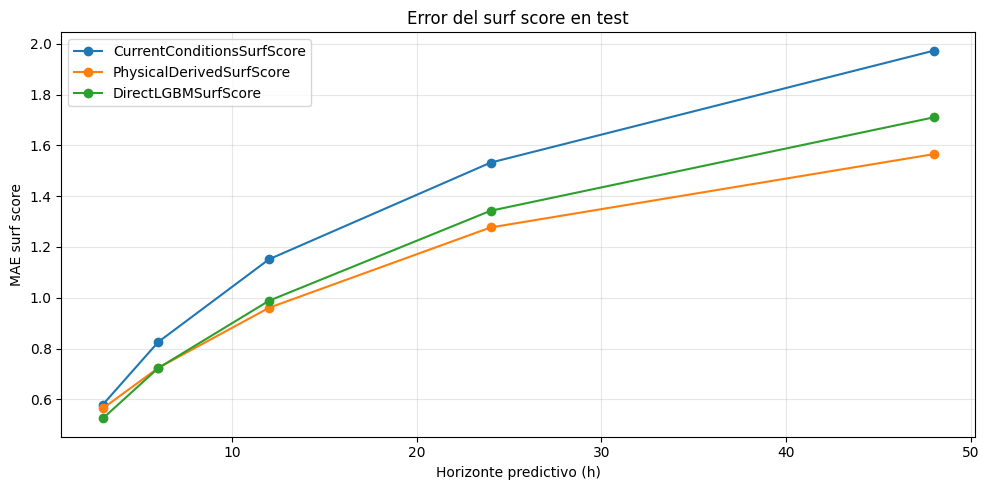

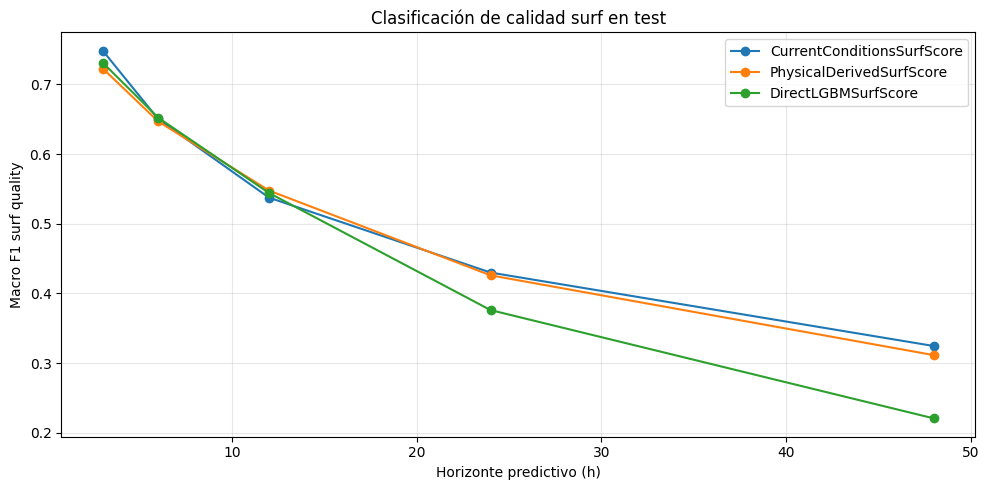

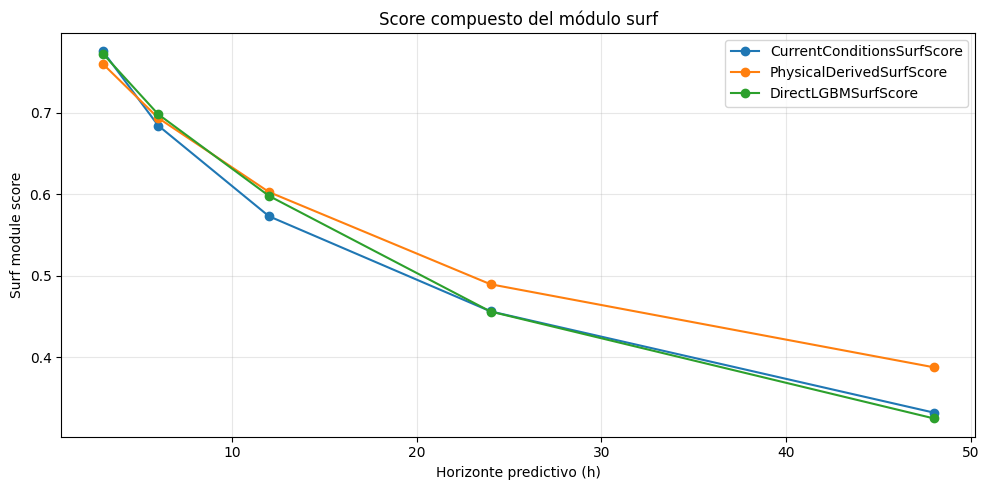

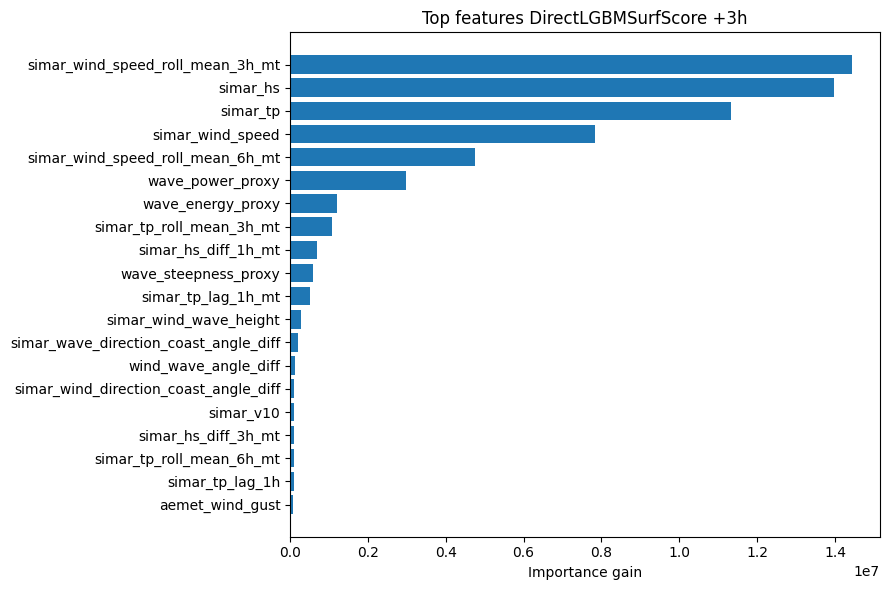

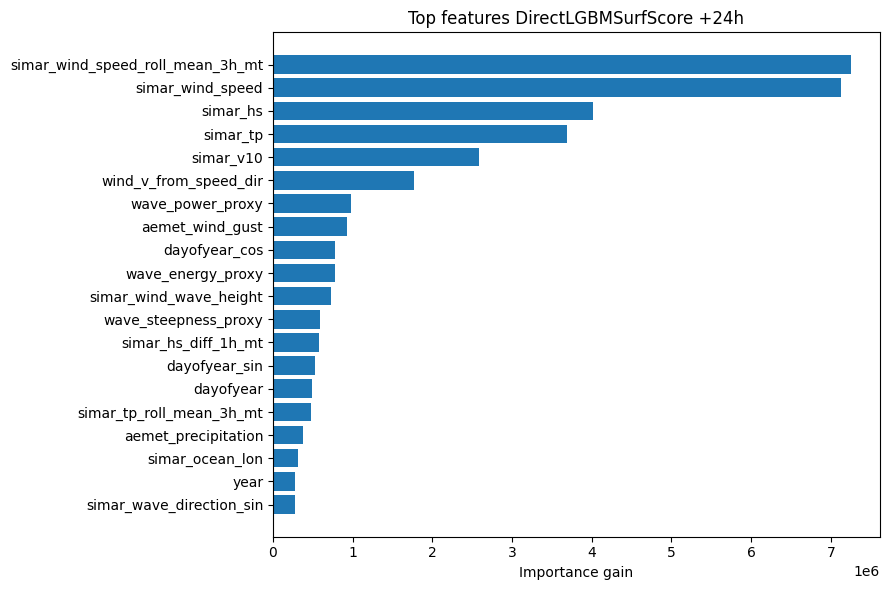

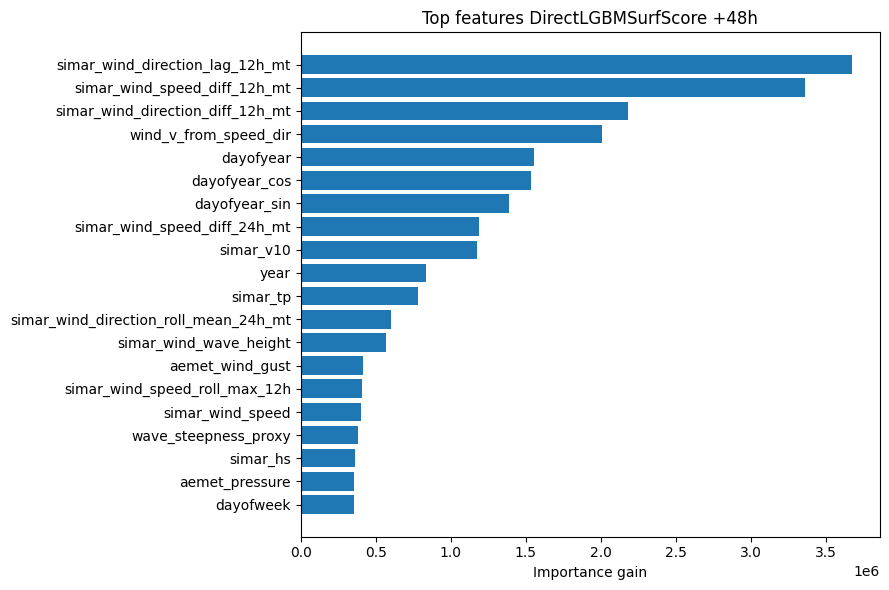

In [13]:
cm_dir = RESULTS_DIR / "confusion_matrices"
cm_dir.mkdir(parents=True, exist_ok=True)

if not predictions_df.empty:
    for (model_name, h, split_name), sub in predictions_df.groupby(["model", "horizon_hours", "split"]):
        if split_name != "test":
            continue

        y_true = sub["y_quality_true"].astype("string").map(QUALITY_TO_INT)
        y_pred = sub["y_quality_pred"].astype("string").map(QUALITY_TO_INT)
        mask = y_true.notna() & y_pred.notna()

        if mask.sum() == 0:
            continue

        cm = confusion_matrix(
            y_true[mask].astype(int),
            y_pred[mask].astype(int),
            labels=list(range(len(QUALITY_ORDER))),
        )

        cm_df = pd.DataFrame(
            cm,
            index=[f"true_{q}" for q in QUALITY_ORDER],
            columns=[f"pred_{q}" for q in QUALITY_ORDER],
        )

        out_path = cm_dir / f"cm_{model_safe_name(model_name)}_{h}h_test.csv"
        cm_df.to_csv(out_path)

if not test_scored.empty:
    plt.figure(figsize=(10, 5))
    for model_name in test_scored["model"].dropna().unique():
        data = test_scored[test_scored["model"] == model_name].sort_values("horizon_hours")
        plt.plot(data["horizon_hours"], data["mae"], marker="o", label=model_name)
    plt.xlabel("Horizonte predictivo (h)")
    plt.ylabel("MAE surf score")
    plt.title("Error del surf score en test")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "plot_surf_score_mae.png", dpi=160)
    plt.show()

    plt.figure(figsize=(10, 5))
    for model_name in test_scored["model"].dropna().unique():
        data = test_scored[test_scored["model"] == model_name].sort_values("horizon_hours")
        plt.plot(data["horizon_hours"], data["quality_macro_f1"], marker="o", label=model_name)
    plt.xlabel("Horizonte predictivo (h)")
    plt.ylabel("Macro F1 surf quality")
    plt.title("Clasificación de calidad surf en test")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "plot_surf_quality_macro_f1.png", dpi=160)
    plt.show()

    plt.figure(figsize=(10, 5))
    for model_name in test_scored["model"].dropna().unique():
        data = test_scored[test_scored["model"] == model_name].sort_values("horizon_hours")
        plt.plot(data["horizon_hours"], data["surf_module_score"], marker="o", label=model_name)
    plt.xlabel("Horizonte predictivo (h)")
    plt.ylabel("Surf module score")
    plt.title("Score compuesto del módulo surf")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "plot_surf_module_score.png", dpi=160)
    plt.show()

if not top_features.empty:
    for h in [3, 24, 48]:
        plot_df = (
            top_features[
                (top_features["horizon_hours"] == h)
                & (top_features["model"] == "DirectLGBMSurfScore")
            ]
            .head(20)
            .sort_values("importance_gain", ascending=True)
        )

        if plot_df.empty:
            continue

        plt.figure(figsize=(9, 6))
        plt.barh(plot_df["feature"], plot_df["importance_gain"])
        plt.xlabel("Importance gain")
        plt.title(f"Top features DirectLGBMSurfScore +{h}h")
        plt.tight_layout()
        plt.savefig(RESULTS_DIR / f"plot_top_features_surf_score_{h}h.png", dpi=160)
        plt.show()

## Celda 13 — Informe ejecutivo

In [14]:
report_lines = []
report_lines.append("# Surf score module — DeepWave Canarias\n")
report_lines.append("## Dataset\n")
report_lines.append(f"- Entrada: `{INPUT_GOLD_DIR}`")
report_lines.append(f"- Filas: {len(gold):,}")
report_lines.append(f"- Columnas: {len(gold.columns):,}")
report_lines.append(f"- Horizontes: {HORIZONS_HOURS}")
report_lines.append(f"- Predicciones físicas disponibles: {PHYSICAL_PREDICTIONS_PATH.exists()}")
report_lines.append(f"- DirectLGBMSurfScore entrenado: {TRAIN_DIRECT_LGBM_SCORE}")
report_lines.append("\n## Interpretación\n")
report_lines.append("El surf score es un índice físico de 0 a 10 basado en altura de ola, periodo, viento y orientación costera.")
report_lines.append("No procede de etiquetas reales de surfistas, por lo que se recomienda usarlo como módulo interpretable basado en reglas físicas.\n")
report_lines.append("## Recomendación por horizonte\n")

if not recommendation_df.empty:
    for _, row in recommendation_df.iterrows():
        report_lines.append(
            f"- +{int(row['horizon_hours'])}h: {row['recommended_model']} "
            f"(MAE={row['recommended_mae']:.4f}, RMSE={row['recommended_rmse']:.4f}, "
            f"macro_f1_quality={row['recommended_quality_macro_f1']:.4f}, "
            f"balanced_acc_quality={row['recommended_quality_balanced_accuracy']:.4f}, "
            f"score={row['recommended_score']:.4f})"
        )

report_lines.append("\n## Nota metodológica\n")
report_lines.append("Si DirectLGBMSurfScore obtiene métricas altas, debe interpretarse como un modelo sustituto que aprende reglas ya definidas.")
report_lines.append("Para la versión final del sistema se prioriza PhysicalDerivedSurfScore por estar conectado a las predicciones físicas de oleaje y viento.")

report_md = "\n".join(report_lines)

(RESULTS_DIR / "surf_score_report.md").write_text(report_md, encoding="utf-8")

summary_json = {
    "dataset": str(INPUT_GOLD_DIR),
    "results_dir": str(RESULTS_DIR),
    "models_dir": str(MODELS_DIR),
    "rows": int(len(gold)),
    "columns": int(len(gold.columns)),
    "horizons_hours": HORIZONS_HOURS,
    "quality_order": QUALITY_ORDER,
    "physical_predictions_available": bool(PHYSICAL_PREDICTIONS_PATH.exists()),
    "train_direct_lgbm_score": bool(TRAIN_DIRECT_LGBM_SCORE),
    "direct_models_trained": training_summary_df.to_dict(orient="records") if "training_summary_df" in globals() and not training_summary_df.empty else [],
    "recommendations": recommendation_df.to_dict(orient="records") if "recommendation_df" in globals() and not recommendation_df.empty else [],
    "surf_score_config": SURF_SCORE_CONFIG,
}

save_json(summary_json, RESULTS_DIR / "surf_score_summary.json")
save_json(summary_json, MODELS_DIR / "surf_score_summary.json")

print(report_md[:4000])
print("\nInforme guardado:", RESULTS_DIR / "surf_score_report.md")

# Surf score module — DeepWave Canarias

## Dataset

- Entrada: `/Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/multitarget_training_dataset`
- Filas: 983,328
- Columnas: 673
- Horizontes: [3, 6, 12, 24, 48]
- Predicciones físicas disponibles: True
- DirectLGBMSurfScore entrenado: True

## Interpretación

El surf score es un índice físico de 0 a 10 basado en altura de ola, periodo, viento y orientación costera.
No procede de etiquetas reales de surfistas, por lo que se recomienda usarlo como módulo interpretable basado en reglas físicas.

## Recomendación por horizonte

- +3h: CurrentConditionsSurfScore (MAE=0.5797, RMSE=1.0514, macro_f1_quality=0.7483, balanced_acc_quality=0.7521, score=0.7754)
- +6h: DirectLGBMSurfScore (MAE=0.7234, RMSE=1.0609, macro_f1_quality=0.6522, balanced_acc_quality=0.6415, score=0.6980)
- +12h: PhysicalDerivedSurfScore (MAE=0.9606, RMSE=1.4693, macro_f1_quality=0.5476, balanced_acc_quality=0.5255, score=0.6027)
- +24h: PhysicalDe

## Celda 14 — Validación final

In [15]:
required_files = [
    RESULTS_DIR / "surf_target_inventory.csv",
    RESULTS_DIR / "metrics_surf_score.csv",
    RESULTS_DIR / "test_metrics_surf_score.csv",
    RESULTS_DIR / "test_metrics_surf_score_scored.csv",
    RESULTS_DIR / "recommendation_by_horizon.csv",
    RESULTS_DIR / "surf_score_report.md",
    RESULTS_DIR / "surf_score_summary.json",
    MODELS_DIR / "surf_score_summary.json",
]

if TRAIN_DIRECT_LGBM_SCORE:
    required_files.extend([
        RESULTS_DIR / "feature_selection_audit.csv",
        RESULTS_DIR / "feature_metadata.json",
        RESULTS_DIR / "training_summary.csv",
        RESULTS_DIR / "feature_importance.csv",
        MODELS_DIR / "feature_metadata.json",
    ])

missing = [str(p) for p in required_files if not p.exists()]

if missing:
    raise FileNotFoundError("Faltan archivos requeridos: " + json.dumps(missing, indent=2))

if metrics_df.empty:
    raise ValueError("No se generaron métricas de surf score.")

if test_scored.empty:
    raise ValueError("No se generaron métricas test del módulo surf.")

if recommendation_df.empty:
    raise ValueError("No se generó recomendación final por horizonte.")

print("Métricas test:")
display(test_scored.sort_values(["horizon_hours", "surf_module_score"], ascending=[True, False]))

print("\nRecomendación final:")
display(recommendation_df)

print("\nArchivos principales:")
for p in required_files:
    print("-", p)

model_files = list(MODELS_DIR.rglob("*.pkl"))
print("\nModelos DirectLGBMSurfScore guardados:", len(model_files))
for p in model_files[:20]:
    print("-", p)

print("\n✅ Módulo surf score completado correctamente.")

Métricas test:


,model,horizon_hours,split,n,mae,rmse,r2,bias,corr,n_quality,...,quality_precision_very_good,quality_recall_very_good,quality_f1_very_good,quality_support_very_good,quality_precision_epic,quality_recall_epic,quality_f1_epic,quality_support_epic,best_iteration,surf_module_score
0,CurrentConditionsSurfScore,3,test,197256,0.579702,1.051352,0.790348,0.061757,0.893943,197256,...,0.717612,0.725072,0.721322,45019,0.823342,0.817584,0.820453,50763,NaN,0.775391
27,DirectLGBMSurfScore,3,test,197256,0.525273,0.823178,0.871474,-0.000614,0.933556,197256,...,0.633740,0.757591,0.690153,45019,0.860827,0.715364,0.781383,50763,2496.0,0.772385
15,PhysicalDerivedSurfScore,3,test,197043,0.564786,0.950408,0.827976,-0.174368,0.913499,197043,...,0.664298,0.533664,0.591858,45019,0.737480,0.836633,0.783934,50763,NaN,0.759874
30,DirectLGBMSurfScore,6,test,197256,0.723377,1.060879,0.787406,0.009571,0.887438,197256,...,0.528397,0.714263,0.607430,44926,0.830433,0.612752,0.705176,50704,1218.0,0.698044
17,PhysicalDerivedSurfScore,6,test,196830,0.724116,1.169163,0.739694,-0.123093,0.863488,196830,...,0.571262,0.478654,0.520873,44926,0.699729,0.788892,0.741640,50704,NaN,0.693502
3,CurrentConditionsSurfScore,6,test,197256,0.826041,1.359972,0.650636,0.067836,0.822678,197256,...,0.610922,0.618551,0.614712,44926,0.746965,0.742604,0.744778,50704,NaN,0.684188
19,PhysicalDerivedSurfScore,12,test,196404,0.960601,1.469307,0.589016,-0.027548,0.774974,196404,...,0.464595,0.428230,0.445672,44754,0.639397,0.715042,0.675107,50597,NaN,0.602685
33,DirectLGBMSurfScore,12,test,197256,0.988373,1.374603,0.646022,0.012317,0.803833,197256,...,0.423276,0.680766,0.521995,44754,0.794729,0.454138,0.577990,50597,370.0,0.597950
6,CurrentConditionsSurfScore,12,test,197256,1.151647,1.750517,0.425944,0.079904,0.707281,197256,...,0.489898,0.497922,0.493878,44754,0.643906,0.641500,0.642701,50597,NaN,0.572970
21,PhysicalDerivedSurfScore,24,test,195552,1.276750,1.845385,0.352063,0.124484,0.626317,195552,...,0.367143,0.394549,0.380353,44504,0.553070,0.609197,0.579778,50363,NaN,0.489591



Recomendación final:


,horizon_hours,recommended_model,recommended_score,recommended_mae,recommended_rmse,recommended_quality_macro_f1,recommended_quality_balanced_accuracy,all_models_ranked
0,3,CurrentConditionsSurfScore,0.775391,0.579702,1.051352,0.748335,0.752145,"[{""model"": ""CurrentConditionsSurfScore"", ""surf..."
1,6,DirectLGBMSurfScore,0.698044,0.723377,1.060879,0.652173,0.641450,"[{""model"": ""DirectLGBMSurfScore"", ""surf_module..."
2,12,PhysicalDerivedSurfScore,0.602685,0.960601,1.469307,0.547635,0.525511,"[{""model"": ""PhysicalDerivedSurfScore"", ""surf_m..."
3,24,PhysicalDerivedSurfScore,0.489591,1.276750,1.845385,0.425966,0.410078,"[{""model"": ""PhysicalDerivedSurfScore"", ""surf_m..."
4,48,PhysicalDerivedSurfScore,0.387827,1.565356,2.161872,0.311439,0.318136,"[{""model"": ""PhysicalDerivedSurfScore"", ""surf_m..."



Archivos principales:
- /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/surf_score/surf_target_inventory.csv
- /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/surf_score/metrics_surf_score.csv
- /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/surf_score/test_metrics_surf_score.csv
- /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/surf_score/test_metrics_surf_score_scored.csv
- /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/surf_score/recommendation_by_horizon.csv
- /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/surf_score/surf_score_report.md
- /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/surf_score/surf_score_summary.json
- /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canar

## Resultado esperado

Al final debe aparecer:

```text
✅ Módulo surf score completado correctamente.
```

Salidas principales:

```text
models/surf_score/
gold/model_results/surf_score/
```

Archivos clave:

```text
metrics_surf_score.csv
test_metrics_surf_score.csv
test_metrics_surf_score_scored.csv
recommendation_by_horizon.csv
predictions_val_test_surf_score.parquet
surf_score_report.md
surf_score_summary.json
```

Después de este notebook, el siguiente paso recomendado es:

```text
18_model_final_report_multitarget.ipynb
```